# Backend Floor Planner And Depth Workflow Test

Run this notebook before testing inside SketchUp. It calls the hosted backend over HTTP so the same backend logs used by SketchUp are exercised.

Coverage:
- backend health and route availability through the hosted API
- generated viewport upload through `/uploads/viewport`
- real depth estimation and point-cloud generation through `/generate/point-cloud`
- textured OBJ colored mesh generation with `.mtl` and texture sidecars
- artifact download for generated depth preview, point-cloud, mesh, and mesh sidecar files
- floor-plan discussion draft capture
- continued discussion with `temporary_floor_plan_draft`
- LLM-supported decoration JSON and floor-plan SVG plotting tools through `/agent/orchestrate`
- artifact download for generated decoration JSON, SVG, and PNG preview
- whole-plan two-option 16:9 panorama generation through direct `/generate/panorama` backend tool
- panorama depth and point-cloud generation for each panorama option

In [1]:
import base64
import json
import os
import urllib.error
import urllib.request
import socket
from pathlib import Path

REPO_ROOT = Path.cwd()
BACKEND_ROOT = REPO_ROOT / "backend"
BACKEND_URL = os.getenv("BACKEND_URL", "http://192.168.50.242:8000").rstrip("/")
REQUEST_TIMEOUT_SECONDS = int(os.getenv("NOTEBOOK_REQUEST_TIMEOUT_SECONDS", "240"))
PANORAMA_TIMEOUT_SECONDS = int(os.getenv("NOTEBOOK_PANORAMA_TIMEOUT_SECONDS", "720"))

NOTEBOOK_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook-floor-plan"
NOTEBOOK_EXPORT_DIR = REPO_ROOT / "exports" / "notebook-floor-plan"
NOTEBOOK_POINTCLOUD_DIR = REPO_ROOT / "pointclouds" / "notebook-floor-plan"
NOTEBOOK_PANORAMA_DIR = NOTEBOOK_OUTPUT_DIR / "panorama"
NOTEBOOK_PANORAMA_DEPTH_DIR = NOTEBOOK_POINTCLOUD_DIR / "panorama"
NOTEBOOK_MESH_DIR = NOTEBOOK_POINTCLOUD_DIR / "mesh"
NOTEBOOK_ROOM_RENDER_DIR = NOTEBOOK_OUTPUT_DIR / "room_render"
for path in (NOTEBOOK_OUTPUT_DIR, NOTEBOOK_EXPORT_DIR, NOTEBOOK_POINTCLOUD_DIR, NOTEBOOK_PANORAMA_DEPTH_DIR, NOTEBOOK_MESH_DIR, NOTEBOOK_ROOM_RENDER_DIR, NOTEBOOK_PANORAMA_DIR):
    path.mkdir(parents=True, exist_ok=True)

assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY is required because FloorPlanPlotTool owns SVG plotting."

class ApiResponse:
    def __init__(self, status_code: int, body: bytes):
        self.status_code = status_code
        self.content = body
        self.text = body.decode("utf-8", errors="replace")

    def json(self):
        return json.loads(self.text)


class HostedBackendClient:
    def __init__(self, base_url: str):
        self.base_url = base_url

    def get(self, path: str, timeout_seconds: int = REQUEST_TIMEOUT_SECONDS) -> ApiResponse:
        return self._request("GET", path, timeout_seconds=timeout_seconds)

    def post(self, path: str, json_body: dict, timeout_seconds: int = REQUEST_TIMEOUT_SECONDS) -> ApiResponse:
        return self._request("POST", path, json_body, timeout_seconds=timeout_seconds)

    def _request(self, method: str, path: str, json_body: dict | None = None, timeout_seconds: int = REQUEST_TIMEOUT_SECONDS) -> ApiResponse:
        body = None if json_body is None else json.dumps(json_body).encode("utf-8")
        headers = {} if body is None else {"Content-Type": "application/json"}
        request = urllib.request.Request(f"{self.base_url}{path}", data=body, headers=headers, method=method)
        try:
            with urllib.request.urlopen(request, timeout=timeout_seconds) as response:
                return ApiResponse(response.status, response.read())
        except urllib.error.HTTPError as exc:
            return ApiResponse(exc.code, exc.read())
        except TimeoutError as exc:
            raise TimeoutError(f"{method} {path} exceeded {timeout_seconds}s. Check backend logs with: docker compose logs -f backend") from exc
        except socket.timeout as exc:
            raise TimeoutError(f"{method} {path} exceeded {timeout_seconds}s. Check backend logs with: docker compose logs -f backend") from exc


client = HostedBackendClient(BACKEND_URL)
print("Backend URL:", BACKEND_URL)
print("Watch backend logs with: docker compose logs -f backend")
print("Backend root:", BACKEND_ROOT)
print("Notebook output dir:", NOTEBOOK_OUTPUT_DIR)
print("Default request timeout seconds:", REQUEST_TIMEOUT_SECONDS)
print("Panorama request timeout seconds:", PANORAMA_TIMEOUT_SECONDS)


Backend URL: http://192.168.50.242:8000
Watch backend logs with: docker compose logs -f backend
Backend root: /Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/backend
Notebook output dir: /Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan
Default request timeout seconds: 240
Panorama request timeout seconds: 720


## 1. Backend Health And Routes

In [2]:
health = client.get("/health")
assert health.status_code == 200
assert health.json() == {"status": "ok"}

openapi = client.get("/openapi.json")
assert openapi.status_code == 200, openapi.text
routes = set(openapi.json()["paths"].keys())
required_routes = {
    "/agent/orchestrate",
    "/artifacts/download",
    "/generate/panorama",
    "/generate/point-cloud",
    "/uploads/viewport",
}
assert required_routes.issubset(routes), sorted(required_routes - routes)

{"health": health.json(), "routes_checked": sorted(required_routes)}


{'health': {'status': 'ok'},
 'routes_checked': ['/agent/orchestrate',
  '/artifacts/download',
  '/generate/panorama',
  '/generate/point-cloud',
  '/uploads/viewport']}

## 2. Shared Render Payload Helper

In [3]:
def valid_render_payload(user_prompt: str) -> dict:
    return {
        "project_id": "notebook-floor-plan",
        "viewport_image_path": "notebook_view.png",
        "style": "modern interior",
        "user_prompt": user_prompt,
        "camera": {
            "position": [1.2, 3.4, 2.1],
            "direction": [0.0, 1.0, -0.2],
            "fov": 45,
        },
        "model": {
            "bounds": {"width": 8.2, "depth": 6.4, "height": 3.1},
            "materials": ["wood", "glass", "concrete"],
            "selected_entity_count": 0,
        },
        "render_options": {
            "preserve_geometry": True,
            "preserve_camera": True,
            "output_resolution": "1024x1024",
        },
    }


## 3. Upload Notebook Viewport For Depth Estimation

This creates a small synthetic viewport image and uploads it through the same endpoint used by the SketchUp plugin before depth estimation.

In [4]:
from PIL import Image as PILImage, ImageDraw

notebook_view_path = NOTEBOOK_EXPORT_DIR / "notebook_view.png"
view_image = PILImage.new("RGB", (256, 256), "#d8dde6")
draw = ImageDraw.Draw(view_image)
draw.rectangle((24, 132, 232, 232), fill="#b68f62", outline="#4b5563", width=3)
draw.rectangle((56, 76, 204, 156), fill="#f5f2ea", outline="#4b5563", width=3)
draw.polygon([(56, 76), (128, 32), (204, 76)], fill="#7f8ea3", outline="#4b5563")
draw.rectangle((106, 164, 148, 232), fill="#6b4f3a", outline="#2f2f2f")
view_image.save(notebook_view_path)

upload_payload = {
    "filename": notebook_view_path.name,
    "content_base64": base64.b64encode(notebook_view_path.read_bytes()).decode("ascii"),
}
upload_response = client.post("/uploads/viewport", json_body=upload_payload)
assert upload_response.status_code == 200, {"status_code": upload_response.status_code, "body": upload_response.text}
uploaded_view = upload_response.json()
assert uploaded_view["image_path"] == notebook_view_path.name

{"uploaded_viewport": uploaded_view, "local_viewport": str(notebook_view_path)}


{'uploaded_viewport': {'status': 'success',
  'image_path': 'notebook_view.png',
  'filename': 'notebook_view.png',
  'size_bytes': 1264},
 'local_viewport': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/exports/notebook-floor-plan/notebook_view.png'}

## 4. Estimate Depth And Generate Point Cloud

This calls the existing backend point-cloud tool. With the real depth model enabled, the response should report the configured model and should not include the deterministic fallback warning.

In [5]:
point_cloud_payload = {
    "image_path": uploaded_view["image_path"],
    "camera": valid_render_payload("depth camera")["camera"],
    "output_format": "ply",
}
point_cloud_response = client.post("/generate/point-cloud", json_body=point_cloud_payload, timeout_seconds=REQUEST_TIMEOUT_SECONDS)
assert point_cloud_response.status_code == 200, {"status_code": point_cloud_response.status_code, "body": point_cloud_response.text}
point_cloud = point_cloud_response.json()

assert point_cloud["status"] == "success", point_cloud
assert point_cloud["pointcloud_path"].endswith(".ply"), point_cloud
assert point_cloud["preview_image_path"].endswith("_depth_preview.png"), point_cloud
assert point_cloud["point_count"] > 0, point_cloud
assert point_cloud["depth_model"], point_cloud
assert point_cloud.get("sidecar_paths", []) == [], point_cloud
assert not any("deterministic fallback" in warning.lower() for warning in point_cloud.get("warnings", [])), point_cloud

{
    "depth_model": point_cloud["depth_model"],
    "point_count": point_cloud["point_count"],
    "pointcloud_path": point_cloud["pointcloud_path"],
    "preview_image_path": point_cloud["preview_image_path"],
    "sidecar_paths": point_cloud.get("sidecar_paths", []),
}


{'depth_model': 'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf',
 'point_count': 65536,
 'pointcloud_path': '/app/pointclouds/pointcloud_20260518_123325_71efa2f5.ply',
 'preview_image_path': '/app/pointclouds/pointcloud_20260518_123325_71efa2f5_depth_preview.png',
 'sidecar_paths': []}

## 5. Download Depth Artifacts

This mirrors the plugin hydrating the generated depth preview and point-cloud file for local preview/reveal/import.

In [6]:
pointcloud_download = client.post("/artifacts/download", json_body={"path": point_cloud["pointcloud_path"]})
preview_download = client.post("/artifacts/download", json_body={"path": point_cloud["preview_image_path"]})
assert pointcloud_download.status_code == 200, pointcloud_download.text
assert preview_download.status_code == 200, preview_download.text

pointcloud_bytes = base64.b64decode(pointcloud_download.json()["content_base64"])
preview_bytes = base64.b64decode(preview_download.json()["content_base64"])
assert pointcloud_bytes.startswith(b"ply\n")
assert preview_bytes.startswith(b"\x89PNG")

local_pointcloud_path = NOTEBOOK_POINTCLOUD_DIR / Path(point_cloud["pointcloud_path"]).name
local_depth_preview_path = NOTEBOOK_POINTCLOUD_DIR / Path(point_cloud["preview_image_path"]).name
local_pointcloud_path.write_bytes(pointcloud_bytes)
local_depth_preview_path.write_bytes(preview_bytes)

{
    "local_pointcloud_path": str(local_pointcloud_path),
    "local_depth_preview_path": str(local_depth_preview_path),
    "pointcloud_size_bytes": len(pointcloud_bytes),
    "depth_preview_size_bytes": len(preview_bytes),
}


{'local_pointcloud_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/pointcloud_20260518_123325_71efa2f5.ply',
 'local_depth_preview_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/pointcloud_20260518_123325_71efa2f5_depth_preview.png',
 'pointcloud_size_bytes': 2561363,
 'depth_preview_size_bytes': 15808}

## 5b. Generate And Download Colored Mesh OBJ

This validates the colored mesh path for `output_format: "obj"`. The backend should return a textured OBJ plus `.mtl` and texture PNG sidecars, and all artifacts should download through `/artifacts/download`.


In [7]:
mesh_payload = {
    "image_path": uploaded_view["image_path"],
    "camera": valid_render_payload("mesh camera")["camera"],
    "output_format": "obj",
}
mesh_response = client.post("/generate/point-cloud", json_body=mesh_payload, timeout_seconds=REQUEST_TIMEOUT_SECONDS)
assert mesh_response.status_code == 200, {"status_code": mesh_response.status_code, "body": mesh_response.text}
colored_mesh = mesh_response.json()

assert colored_mesh["status"] == "success", colored_mesh
assert colored_mesh["output_format"] == "obj", colored_mesh
assert colored_mesh["pointcloud_path"].endswith(".obj"), colored_mesh
assert colored_mesh["preview_image_path"].endswith("_depth_preview.png"), colored_mesh
assert colored_mesh["point_count"] > 0, colored_mesh
assert colored_mesh["depth_model"], colored_mesh
mesh_sidecar_paths = colored_mesh.get("sidecar_paths", [])
assert len(mesh_sidecar_paths) == 2, colored_mesh
assert {Path(path).suffix for path in mesh_sidecar_paths} == {".mtl", ".png"}, colored_mesh

mesh_backend_paths = [colored_mesh["pointcloud_path"], *mesh_sidecar_paths, colored_mesh["preview_image_path"]]
local_mesh_paths = []
for backend_path in mesh_backend_paths:
    download = client.post("/artifacts/download", json_body={"path": backend_path})
    assert download.status_code == 200, {"path": backend_path, "body": download.text}
    artifact_bytes = base64.b64decode(download.json()["content_base64"])
    local_path = NOTEBOOK_MESH_DIR / Path(backend_path).name
    local_path.write_bytes(artifact_bytes)
    local_mesh_paths.append(local_path)

obj_path = next(path for path in local_mesh_paths if path.suffix == ".obj")
mtl_path = next(path for path in local_mesh_paths if path.suffix == ".mtl")
texture_path = next(path for path in local_mesh_paths if path.name.endswith("_texture.png"))
obj_text = obj_path.read_text(encoding="ascii")
mtl_text = mtl_path.read_text(encoding="ascii")
assert "mtllib " in obj_text, obj_text[:500]
assert "usemtl panorama_floorplan_texture" in obj_text, obj_text[:500]
assert "\nvt " in obj_text, obj_text[:500]
assert any(line.startswith("f ") and "/" in line for line in obj_text.splitlines()), obj_text[-500:]
assert f"map_Kd {texture_path.name}" in mtl_text, mtl_text
assert texture_path.read_bytes().startswith(b"\x89PNG"), texture_path

{
    "colored_mesh_path": str(obj_path),
    "mesh_sidecars": [str(path) for path in local_mesh_paths if path in {mtl_path, texture_path}],
    "point_count": colored_mesh["point_count"],
}


{'colored_mesh_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/mesh/pointcloud_20260518_123326_e3e3279a.obj',
 'mesh_sidecars': ['/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/mesh/pointcloud_20260518_123326_e3e3279a.mtl',
  '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/mesh/pointcloud_20260518_123326_e3e3279a_texture.png'],
 'point_count': 65536}

## 6. Display Depth Preview

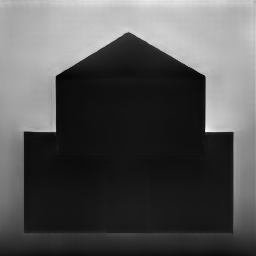

{'displayed_depth_preview': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/pointcloud_20260518_123325_71efa2f5_depth_preview.png'}

In [8]:
from IPython.display import Image as DisplayImage, display

display(DisplayImage(filename=str(local_depth_preview_path)))
{"displayed_depth_preview": str(local_depth_preview_path)}


## 7. Discussion Draft Capture

This tests the backend discussion step that SketchUp uses before showing `Plot Floor Plan`.

In [9]:
discussion_payload = valid_render_payload(
    "Floor plan for " \
    "1. Must be rectangular shape. "\
    "2. Living with front door, width 10, height 20, " \
    "3. Kitchen with width 10, height 10, " \
    "4. Office with width 10, height 10. " \
    "5. Living has door to Office, but no door to Kitchen. "\
    "6. A wall between Kitchen and Office."\
    "7. Connection (Living, Kitchen), (Living, Office). "
    
)
discussion_response = client.post("/agent/orchestrate", json_body=discussion_payload)
assert discussion_response.status_code == 200, discussion_response.text
discussion = discussion_response.json()

assert discussion["intent"] == "floor_plan_discuss"
assert discussion["assigned_agent"] == "FloorPlanDiscussionAgent"
assert discussion["floor_plan_ready"] is True
assert discussion["floor_plan_missing_fields"] == []
assert discussion["floor_plan_draft"]["rooms"]

floor_plan_draft = discussion["floor_plan_draft"]
{"rooms": floor_plan_draft["rooms"], "ready": discussion["floor_plan_ready"]}


{'rooms': [{'name': 'Living',
   'width': 10.0,
   'depth': 20.0,
   'label': 'Living with front door'},
  {'name': 'Kitchen', 'width': 10.0, 'depth': 10.0, 'label': 'Kitchen'},
  {'name': 'Office', 'width': 10.0, 'depth': 10.0, 'label': 'Office'}],
 'ready': True}

## 8. Continued Discussion With Existing Draft State

This mirrors the dialog sending `temporary_floor_plan_draft` on the next chat turn.

In [10]:
# continued_payload = valid_render_payload("Office 20x10 connected to Kitchen")
# continued_payload["temporary_floor_plan_draft"] = floor_plan_draft
# continued_response = client.post("/agent/orchestrate", json_body=continued_payload)
# assert continued_response.status_code == 200, continued_response.text
# continued = continued_response.json()

# assert continued["intent"] == "floor_plan_discuss"
# assert continued["floor_plan_ready"] is True

# floor_plan_draft = continued["floor_plan_draft"]
room_names = [room["name"] for room in floor_plan_draft["rooms"]]
assert room_names == ["Living", "Kitchen", "Office"], room_names
room_names


['Living', 'Kitchen', 'Office']

## 9. Plot Through `/agent/orchestrate`

This mirrors clicking `Plot Floor Plan` in SketchUp.

In [11]:
plot_payload = valid_render_payload("plot the floor plan")
plot_payload["temporary_floor_plan_draft"] = floor_plan_draft
plot_response = client.post("/agent/orchestrate", json_body=plot_payload)
assert plot_response.status_code == 200, plot_response.text
plot = plot_response.json()

assert plot["intent"] == "floor_plan_plot"
assert plot["assigned_agent"] == "FloorPlanToolchain"
assert plot["floor_plan_ready"] is True
assert plot["floor_plan"]["svg_path"].endswith(".svg")
assert plot["floor_plan"]["preview_image_path"].endswith(".png")
assert plot["floor_plan"]["decoration_path"].endswith(".layout.json")
assert [artifact["type"] for artifact in plot["artifacts"]] == ["floor_plan_svg", "floor_plan_png", "floor_plan_decoration_json"]

svg_path = plot["floor_plan"]["svg_path"]
png_path = plot["floor_plan"]["preview_image_path"]
decoration_path = plot["floor_plan"]["decoration_path"]
assert svg_path.endswith(".svg"), svg_path
assert png_path.endswith(".png"), png_path
assert decoration_path.endswith(".layout.json"), decoration_path

plot["floor_plan"]


{'status': 'success',
 'artifact_id': 'floorplan_20260518_123336_17f6f420',
 'svg_path': '/app/outputs/floorplan_20260518_123336_17f6f420.svg',
 'preview_image_path': '/app/outputs/floorplan_20260518_123336_17f6f420.png',
 'decoration_path': '/app/outputs/floorplan_20260518_123336_17f6f420.layout.json',
 'room_count': 3,
 'warnings': [],
 'error_message': None}

## 10. Artifact Download Endpoint

In [12]:
svg_download = client.post("/artifacts/download", json_body={"path": svg_path})
png_download = client.post("/artifacts/download", json_body={"path": png_path})
decoration_download = client.post("/artifacts/download", json_body={"path": decoration_path})
assert svg_download.status_code == 200, svg_download.text
assert png_download.status_code == 200, png_download.text
assert decoration_download.status_code == 200, decoration_download.text

svg_bytes = base64.b64decode(svg_download.json()["content_base64"])
png_bytes = base64.b64decode(png_download.json()["content_base64"])
decoration_bytes = base64.b64decode(decoration_download.json()["content_base64"])
assert svg_bytes.startswith(b"<svg")
assert png_bytes.startswith(b"\x89PNG")
decoration = json.loads(decoration_bytes.decode("utf-8"))
assert decoration["decorated_layout"]["rooms"]
assert decoration["decorated_layout"]["doors"]
assert decoration["decorated_layout"]["furniture"]

local_svg_path = NOTEBOOK_OUTPUT_DIR / Path(svg_path).name
local_png_path = NOTEBOOK_OUTPUT_DIR / Path(png_path).name
local_decoration_path = NOTEBOOK_OUTPUT_DIR / Path(decoration_path).name
local_svg_path.write_bytes(svg_bytes)
local_png_path.write_bytes(png_bytes)
local_decoration_path.write_bytes(decoration_bytes)

{
    "svg_size_bytes": len(svg_bytes),
    "png_size_bytes": len(png_bytes),
    "decoration_size_bytes": len(decoration_bytes),
    "backend_svg_path": svg_path,
    "backend_png_path": png_path,
    "backend_decoration_path": decoration_path,
    "local_svg_path": str(local_svg_path),
    "local_png_path": str(local_png_path),
    "local_decoration_path": str(local_decoration_path),
}


{'svg_size_bytes': 4938,
 'png_size_bytes': 10835,
 'decoration_size_bytes': 4302,
 'backend_svg_path': '/app/outputs/floorplan_20260518_123336_17f6f420.svg',
 'backend_png_path': '/app/outputs/floorplan_20260518_123336_17f6f420.png',
 'backend_decoration_path': '/app/outputs/floorplan_20260518_123336_17f6f420.layout.json',
 'local_svg_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan/floorplan_20260518_123336_17f6f420.svg',
 'local_png_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan/floorplan_20260518_123336_17f6f420.png',
 'local_decoration_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan/floorplan_20260518_123336_17f6f420.layout.json'}

## 11. Display Floor Plan Before Panorama

This confirms the plotted floor plan visually before the panorama backend tool uses its decoration JSON.

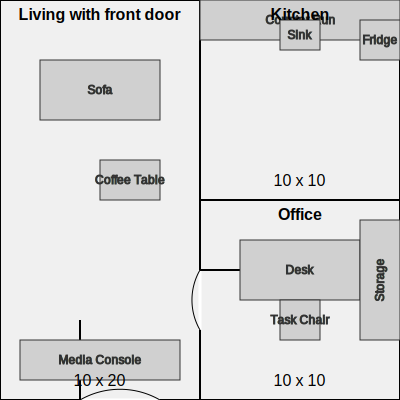

{'displayed_floor_plan': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan/floorplan_20260518_123336_17f6f420.svg',
 'display_mode': 'svg',
 'authoritative_floor_plan_svg': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan/floorplan_20260518_123336_17f6f420.svg',
 'panorama_decoration_path': '/app/outputs/floorplan_20260518_123336_17f6f420.layout.json'}

In [13]:
from IPython.display import Image, SVG, display
from xml.parsers.expat import ExpatError

try:
    display(SVG(filename=str(local_svg_path)))
    floor_plan_display_path = local_svg_path
    floor_plan_display_mode = "svg"
except ExpatError:
    display(Image(filename=str(local_png_path)))
    floor_plan_display_path = local_png_path
    floor_plan_display_mode = "png_fallback"

{
    "displayed_floor_plan": str(floor_plan_display_path),
    "display_mode": floor_plan_display_mode,
    "authoritative_floor_plan_svg": str(local_svg_path),
    "panorama_decoration_path": decoration_path,
}


## 12. Generate Whole-Plan Panorama

This tests the direct backend panorama tool. It requires only the plotted floor-plan decoration JSON and must call `/generate/panorama` directly, not `/agent/orchestrate`.

In [14]:
panorama_payload = {
    "decoration_path": decoration_path,
    "style": "modern interior",
    "output_resolution": "1024x576",
}
panorama_response = client.post("/generate/panorama", json_body=panorama_payload, timeout_seconds=PANORAMA_TIMEOUT_SECONDS)
assert panorama_response.status_code == 200, panorama_response.text
panorama = panorama_response.json()

assert panorama["status"] == "success", panorama
assert panorama["artifact_id"].startswith("panorama_"), panorama
assert panorama["panorama_image_path"].endswith("_option_1.png"), panorama
assert len(panorama["panorama_image_paths"]) == 2, panorama
assert panorama["panorama_image_path"] == panorama["panorama_image_paths"][0], panorama
assert "left_image_path" not in panorama, panorama
assert "right_image_path" not in panorama, panorama
assert "floor-plan center coordinate" in panorama["scene_description"], panorama["scene_description"]
assert "left hemisphere direction" in panorama["scene_description"], panorama["scene_description"]
assert "Living" in panorama["scene_description"], panorama["scene_description"]

{
    "panorama_status": panorama["status"],
    "panorama_image_path": panorama["panorama_image_path"],
    "panorama_image_paths": panorama["panorama_image_paths"],
    "scene_description_excerpt": panorama["scene_description"][:320],
}


{'panorama_status': 'success',
 'panorama_image_path': '/app/outputs/panorama_20260518_123421_077a7bc6_option_1.png',
 'panorama_image_paths': ['/app/outputs/panorama_20260518_123421_077a7bc6_option_1.png',
  '/app/outputs/panorama_20260518_123421_077a7bc6_option_2.png'],
 'scene_description_excerpt': 'The viewer is a standing person at the floor-plan center coordinate (10.00, 10.00). Positive X is the front seam reference, negative X is behind, positive Y is the left hemisphere direction, and negative Y is the right hemisphere direction. Rooms: Living is 10 by 20 units and lies behind of the viewer; Kitchen is 10 by'}

## 13. Download Panorama Artifacts

In [15]:
from PIL import Image as PILImage

panorama_artifact_paths = {
    f"option_{index}": path
    for index, path in enumerate(panorama["panorama_image_paths"], start=1)
}
local_panorama_paths = {}
for label, backend_path in panorama_artifact_paths.items():
    download = client.post("/artifacts/download", json_body={"path": backend_path})
    assert download.status_code == 200, download.text
    image_bytes = base64.b64decode(download.json()["content_base64"])
    assert image_bytes.startswith(b"\x89PNG"), (label, backend_path)
    local_path = NOTEBOOK_PANORAMA_DIR / Path(backend_path).name
    local_path.write_bytes(image_bytes)
    local_panorama_paths[label] = local_path

panorama_sizes = {label: PILImage.open(path).size for label, path in local_panorama_paths.items()}
assert set(panorama_sizes.values()) == {(1024, 576)}, panorama_sizes

{
    "downloaded_panorama_artifacts": {label: str(path) for label, path in local_panorama_paths.items()},
    "panorama_sizes": panorama_sizes,
}


{'downloaded_panorama_artifacts': {'option_1': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan/panorama/panorama_20260518_123421_077a7bc6_option_1.png',
  'option_2': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/outputs/notebook-floor-plan/panorama/panorama_20260518_123421_077a7bc6_option_2.png'},
 'panorama_sizes': {'option_1': (1024, 576), 'option_2': (1024, 576)}}

## 14. Generate Panorama Depth

This runs the depth/point-cloud endpoint for each generated panorama option so panorama PNGs are validated by the same 3D artifact path used for rendered views.

In [16]:
panorama_depth_results = {}
panorama_depth_camera = valid_render_payload("panorama depth camera")["camera"]

for label, backend_path in panorama_artifact_paths.items():
    payload = {
        "image_path": backend_path,
        "camera": panorama_depth_camera,
        "output_format": "ply",
    }
    response = client.post("/generate/point-cloud", json_body=payload, timeout_seconds=REQUEST_TIMEOUT_SECONDS)
    assert response.status_code == 200, {"label": label, "status_code": response.status_code, "body": response.text}
    result = response.json()
    assert result["status"] == "success", result
    assert result["pointcloud_path"].endswith(".ply"), result
    assert result["preview_image_path"].endswith("_depth_preview.png"), result
    assert result["point_count"] > 0, result
    assert result["depth_model"], result
    assert not any("deterministic fallback" in warning.lower() for warning in result.get("warnings", [])), result
    panorama_depth_results[label] = result

{
    label: {
        "depth_model": result["depth_model"],
        "point_count": result["point_count"],
        "pointcloud_path": result["pointcloud_path"],
        "preview_image_path": result["preview_image_path"],
    }
    for label, result in panorama_depth_results.items()
}


{'option_1': {'depth_model': 'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf',
  'point_count': 23780,
  'pointcloud_path': '/app/pointclouds/pointcloud_20260518_123606_9b909b43.ply',
  'preview_image_path': '/app/pointclouds/pointcloud_20260518_123606_9b909b43_depth_preview.png'},
 'option_2': {'depth_model': 'depth-anything/Depth-Anything-V2-Metric-Indoor-Small-hf',
  'point_count': 23780,
  'pointcloud_path': '/app/pointclouds/pointcloud_20260518_123606_e1bc3001.ply',
  'preview_image_path': '/app/pointclouds/pointcloud_20260518_123606_e1bc3001_depth_preview.png'}}

## 15. Download Panorama Depth And Mesh Artifacts

This downloads the generated panorama PLY and depth-preview PNG artifacts for local inspection. It also generates a textured OBJ mesh from the first panorama option, then downloads the OBJ, MTL, texture PNG, and mesh depth preview sidecars.


In [20]:
local_panorama_depth_paths = {}

for label, result in panorama_depth_results.items():
    pointcloud_download = client.post("/artifacts/download", json_body={"path": result["pointcloud_path"]})
    preview_download = client.post("/artifacts/download", json_body={"path": result["preview_image_path"]})
    assert pointcloud_download.status_code == 200, {"label": label, "body": pointcloud_download.text}
    assert preview_download.status_code == 200, {"label": label, "body": preview_download.text}

    pointcloud_bytes = base64.b64decode(pointcloud_download.json()["content_base64"])
    preview_bytes = base64.b64decode(preview_download.json()["content_base64"])
    assert pointcloud_bytes.startswith(b"ply\n"), label
    assert preview_bytes.startswith(b"\x89PNG"), label

    local_pointcloud_path = NOTEBOOK_PANORAMA_DEPTH_DIR / f"{label}_{Path(result['pointcloud_path']).name}"
    local_depth_preview_path = NOTEBOOK_PANORAMA_DEPTH_DIR / f"{label}_{Path(result['preview_image_path']).name}"
    local_pointcloud_path.write_bytes(pointcloud_bytes)
    local_depth_preview_path.write_bytes(preview_bytes)
    local_panorama_depth_paths[label] = {
        "pointcloud": local_pointcloud_path,
        "preview": local_depth_preview_path,
    }

panorama_mesh_label, panorama_mesh_source_path = next(iter(panorama_artifact_paths.items()))
panorama_mesh_payload = {
    "image_path": panorama_mesh_source_path,
    "camera": panorama_depth_camera,
    "output_format": "obj",
}
panorama_mesh_response = client.post("/generate/point-cloud", json_body=panorama_mesh_payload, timeout_seconds=REQUEST_TIMEOUT_SECONDS)
assert panorama_mesh_response.status_code == 200, {
    "label": panorama_mesh_label,
    "status_code": panorama_mesh_response.status_code,
    "body": panorama_mesh_response.text,
}
panorama_mesh = panorama_mesh_response.json()

assert panorama_mesh["status"] == "success", panorama_mesh
assert panorama_mesh["output_format"] == "obj", panorama_mesh
assert panorama_mesh["pointcloud_path"].endswith(".obj"), panorama_mesh
assert panorama_mesh["preview_image_path"].endswith("_depth_preview.png"), panorama_mesh
assert panorama_mesh["point_count"] > 0, panorama_mesh
panorama_mesh_sidecar_paths = panorama_mesh.get("sidecar_paths", [])
assert len(panorama_mesh_sidecar_paths) == 2, panorama_mesh
assert {Path(path).suffix for path in panorama_mesh_sidecar_paths} == {".mtl", ".png"}, panorama_mesh

panorama_mesh_backend_paths = [
    panorama_mesh["pointcloud_path"],
    *panorama_mesh_sidecar_paths,
    panorama_mesh["preview_image_path"],
]
local_panorama_mesh_dir = NOTEBOOK_PANORAMA_DEPTH_DIR / f"{panorama_mesh_label}_mesh"
local_panorama_mesh_dir.mkdir(parents=True, exist_ok=True)
local_panorama_mesh_paths = []
for backend_path in panorama_mesh_backend_paths:
    download = client.post("/artifacts/download", json_body={"path": backend_path})
    assert download.status_code == 200, {"path": backend_path, "body": download.text}
    artifact_bytes = base64.b64decode(download.json()["content_base64"])
    local_path = local_panorama_mesh_dir / Path(backend_path).name
    local_path.write_bytes(artifact_bytes)
    local_panorama_mesh_paths.append(local_path)

panorama_mesh_obj_path = next(path for path in local_panorama_mesh_paths if path.suffix == ".obj")
panorama_mesh_mtl_path = next(path for path in local_panorama_mesh_paths if path.suffix == ".mtl")
panorama_mesh_texture_path = next(path for path in local_panorama_mesh_paths if path.name.endswith("_texture.png"))
panorama_mesh_preview_path = next(path for path in local_panorama_mesh_paths if path.name.endswith("_depth_preview.png"))

panorama_mesh_obj_text = panorama_mesh_obj_path.read_text(encoding="ascii")
panorama_mesh_mtl_text = panorama_mesh_mtl_path.read_text(encoding="ascii")
assert "mtllib " in panorama_mesh_obj_text, panorama_mesh_obj_text[:500]
assert "usemtl panorama_floorplan_texture" in panorama_mesh_obj_text, panorama_mesh_obj_text[:500]
assert "\nvt " in panorama_mesh_obj_text, panorama_mesh_obj_text[:500]
assert any(line.startswith("f ") and "/" in line for line in panorama_mesh_obj_text.splitlines()), panorama_mesh_obj_text[-500:]
assert f"map_Kd {panorama_mesh_texture_path.name}" in panorama_mesh_mtl_text, panorama_mesh_mtl_text
assert panorama_mesh_texture_path.read_bytes().startswith(b"\x89PNG"), panorama_mesh_texture_path
assert panorama_mesh_preview_path.read_bytes().startswith(b"\x89PNG"), panorama_mesh_preview_path

local_panorama_mesh_result = {
    "source_option": panorama_mesh_label,
    "obj": panorama_mesh_obj_path,
    "mtl": panorama_mesh_mtl_path,
    "texture": panorama_mesh_texture_path,
    "preview": panorama_mesh_preview_path,
    "point_count": panorama_mesh["point_count"],
}

{
    "panorama_depth_artifacts": {
        label: {
            "local_pointcloud_path": str(paths["pointcloud"]),
            "local_depth_preview_path": str(paths["preview"]),
        }
        for label, paths in local_panorama_depth_paths.items()
    },
    "panorama_mesh_artifacts": {key: str(value) for key, value in local_panorama_mesh_result.items() if key != "point_count"},
    "panorama_mesh_point_count": local_panorama_mesh_result["point_count"],
}


{'panorama_depth_artifacts': {'option_1': {'local_pointcloud_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_pointcloud_20260518_123606_9b909b43.ply',
   'local_depth_preview_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_pointcloud_20260518_123606_9b909b43_depth_preview.png'},
  'option_2': {'local_pointcloud_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_2_pointcloud_20260518_123606_e1bc3001.ply',
   'local_depth_preview_path': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_2_pointcloud_20260518_123606_e1bc3001_depth_preview.png'}},
 'panorama_mesh_artifacts': {'source_option': 'option_1',
  'obj': '/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panoram

## 16. Visual Preview

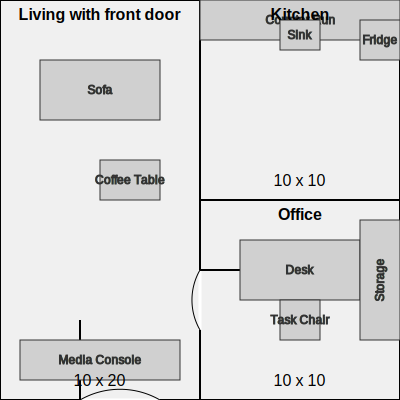

### Whole-plan panorama options

#### option_1

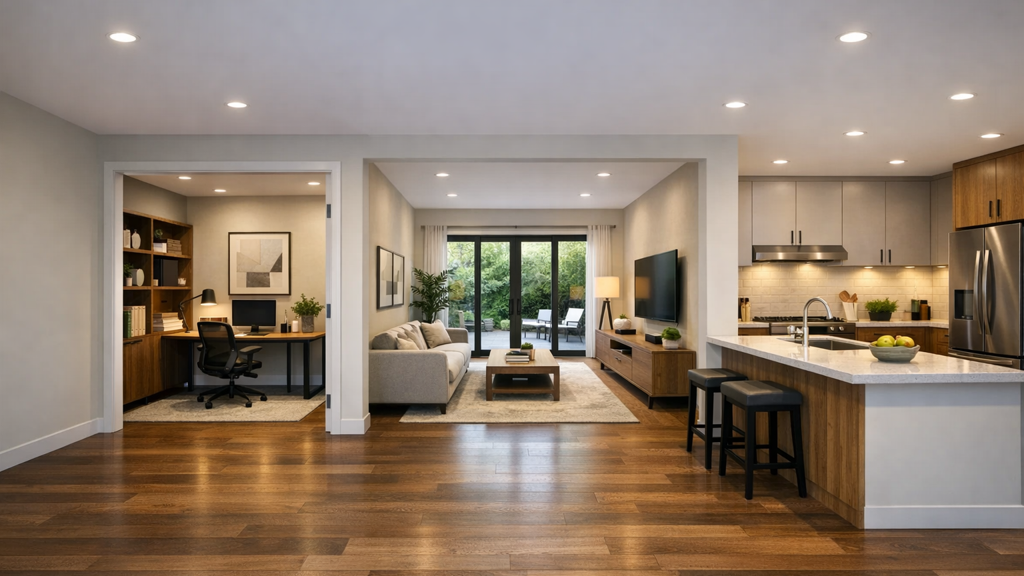

#### option_2

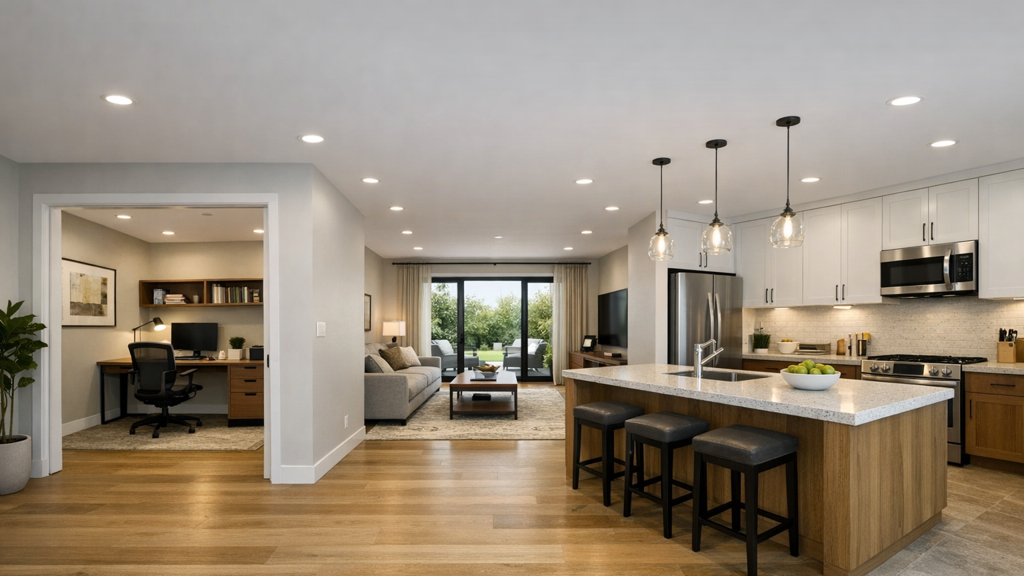

### Panorama depth previews

**option_1 depth**

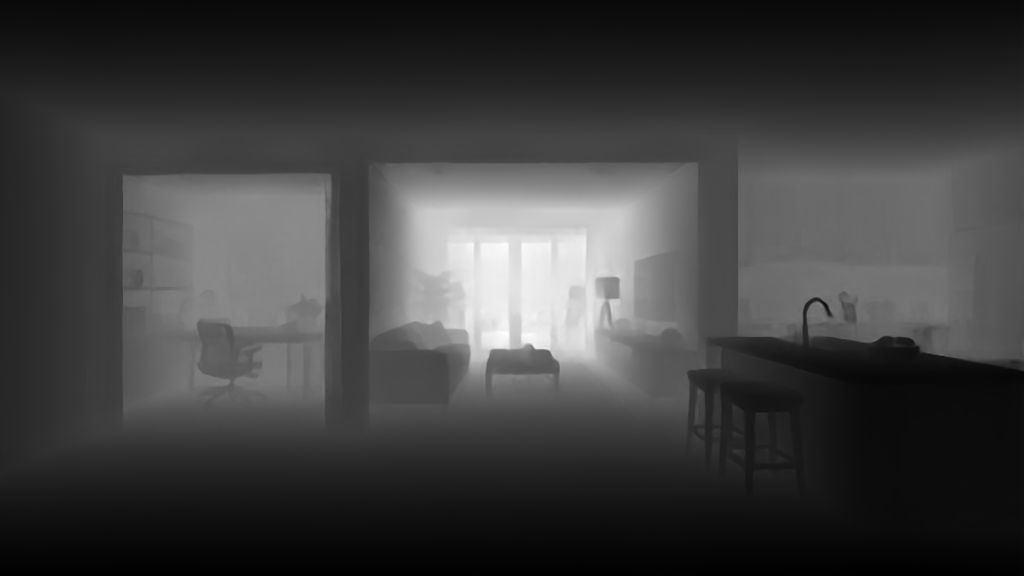

**option_2 depth**

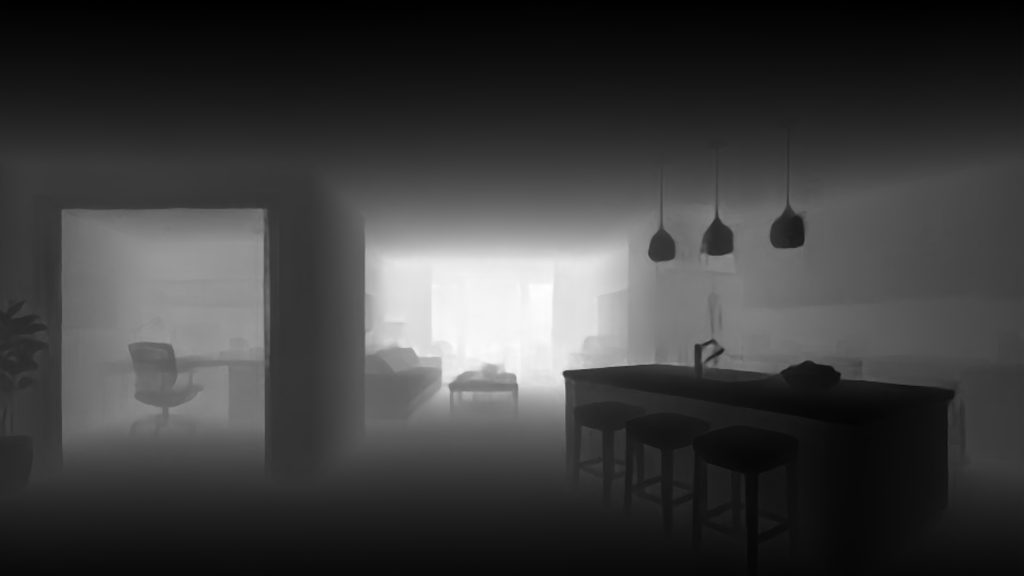

### Panorama colored mesh

**Source:** option_1  
**Point count:** 23780  
Download the OBJ, MTL, and texture together from the same folder so material links stay valid.

**OBJ:** `/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_mesh/pointcloud_20260518_130936_d11ab8fd.obj`

/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_mesh/pointcloud_20260518_130936_d11ab8fd.obj

**MTL:** `/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_mesh/pointcloud_20260518_130936_d11ab8fd.mtl`

...

**Texture PNG:** `/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_mesh/pointcloud_20260518_130936_d11ab8fd_texture.png`

/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_mesh/pointcloud_20260518_130936_d11ab8fd_texture.png

**Depth Preview:** `/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_mesh/pointcloud_20260518_130936_d11ab8fd_depth_preview.png`

/Users/tsungchicheng/Desktop/SketchUp_Agentic_text2image_Plugin/pointclouds/notebook-floor-plan/panorama/option_1_mesh/pointcloud_20260518_130936_d11ab8fd_depth_preview.png

#### Mesh texture

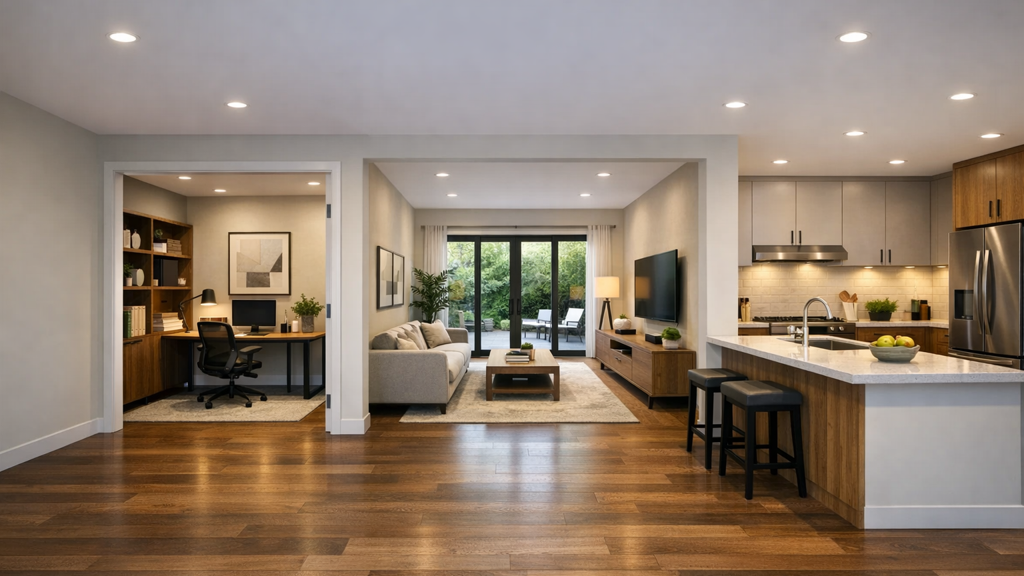

#### Mesh depth preview

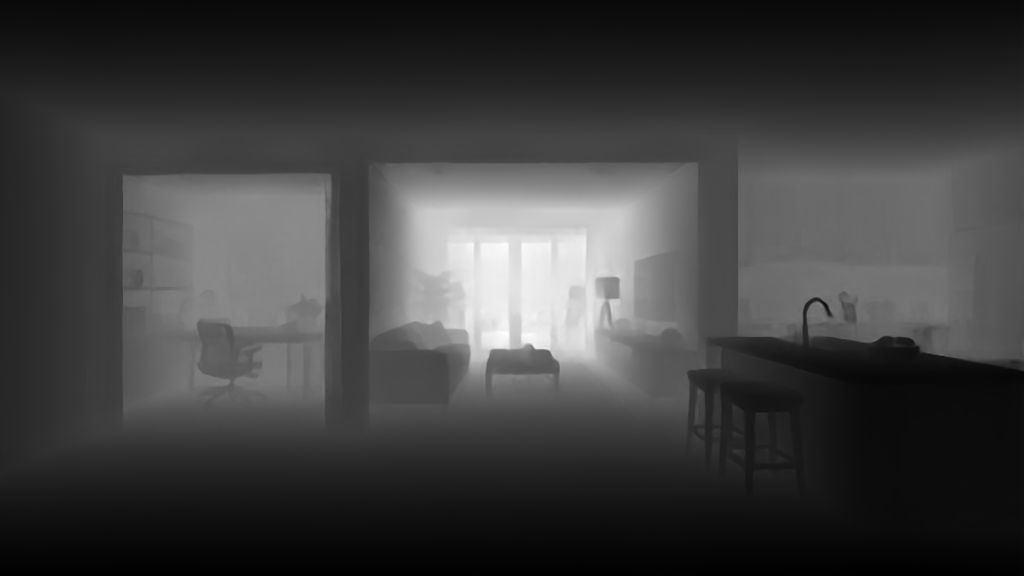

In [21]:
from IPython.display import FileLink, Image, Markdown, SVG, display
from xml.parsers.expat import ExpatError

try:
    display(SVG(filename=str(local_svg_path)))
    floor_plan_display_path = local_svg_path
    floor_plan_display_mode = "svg"
except ExpatError:
    display(Image(filename=str(local_png_path)))
    floor_plan_display_path = local_png_path
    floor_plan_display_mode = "png_fallback"

display(Markdown("### Whole-plan panorama options"))
for label, local_path in local_panorama_paths.items():
    display(Markdown(f"#### {label}"))
    display(Image(filename=str(local_path)))

{
    "authoritative_svg": str(local_svg_path),
    "displayed_floor_plan": str(floor_plan_display_path),
    "display_mode": floor_plan_display_mode,
    "png_placeholder": str(local_png_path),
    "panorama_options": {label: str(path) for label, path in local_panorama_paths.items()},
}

display(Markdown("### Panorama depth previews"))
for label, paths in local_panorama_depth_paths.items():
    display(Markdown(f"**{label} depth**"))
    display(Image(filename=str(paths["preview"])))

display(Markdown("### Panorama colored mesh"))
display(Markdown(
    f"**Source:** {local_panorama_mesh_result['source_option']}  \n"
    f"**Point count:** {local_panorama_mesh_result['point_count']}  \n"
    "Download the OBJ, MTL, and texture together from the same folder so material links stay valid."
))
for label, artifact_key in (("OBJ", "obj"), ("MTL", "mtl"), ("Texture PNG", "texture"), ("Depth Preview", "preview")):
    path = local_panorama_mesh_result[artifact_key]
    display(Markdown(f"**{label}:** `{path}`"))
    display(FileLink(str(path)))

display(Markdown("#### Mesh texture"))
display(Image(filename=str(local_panorama_mesh_result["texture"])))
display(Markdown("#### Mesh depth preview"))
display(Image(filename=str(local_panorama_mesh_result["preview"])))
